# Insight Generation
## Skin-Deep Insights: Aspect-Based Sentiment Analysis of Sephora Reviews

**Purpose:** Convert Stage 5 analytical findings into clear, quantified, executive-language insight statements that directly answer the business problem.

**Business Problem (restated):** Many highly rated beauty products (4★+) still experience high return rates and hidden dissatisfaction. Star ratings alone do not reveal which specific product aspects are causing problems.

**The shift from analysis to insight:**
```
Analysis says:  'Packaging has 11.5% negative sentiment'
Insight says:   'Packaging is the #1 complaint aspect — nearly 1 in 9 
                 packaging mentions is negative, and 2,201 complaints 
                 are hidden inside products customers rated 4★ or higher'
```

**Structure:**
```

Section 1  — Load results from Stage 7
Section 2  — Insight 1: The Hidden Dissatisfaction Problem
Section 3  — Insight 2: Packaging Is The #1 Complaint Aspect
Section 4  — Insight 3: Skin Reactions Are The Most Dangerous Signal
Section 5  — Insight 4: Texture Dominates By Volume
Section 6  — Insight 5: Oily Skin Users Are Underserved
Section 7  — Insight 6: Luxury Products Fail On Value Expectations
Section 8  — Insight 7: Scent And Hydration Are Brand Strengths
Section 9  — Master Insight Summary Table
Section 10 — Business Priority Matrix

```
---

## Section 1 — Load Stage 7 Results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set(style='whitegrid')

# Load clean dataset
df = pd.read_csv('../sephora/clean_reviews.csv', parse_dates=['review_date'])

# Rebuild price tier
df['price_tier'] = pd.cut(
    df['price_usd'],
    bins=[0, 25, 50, 100, 9999],
    labels=['budget(<$25)', 'mid($25-50)', 'premium($50-100)', 'luxury($100+)']
)

# Reproducible sample — same as Stage 7
df_sample = df.sample(n=300000, random_state=42).copy()

print(f'Full dataset: {df.shape}')
print(f'Sample: {df_sample.shape}')

Full dataset: (1033710, 11)
Sample: (300000, 11)


In [2]:
# Rebuild VADER scores
analyzer = SentimentIntensityAnalyzer()
df_sample['vader_score'] = df_sample['review_text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)
df_sample['sentiment_label'] = df_sample['vader_score'].apply(
    lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
)

# Rebuild aspect extraction
aspect_keywords = {
    'packaging':     ['pump', 'bottle', 'packaging', 'break', 'broke',
                      'leaked', 'cap', 'tube'],
    'skin_reaction': ['breakout', 'acne', 'irritation', 'rash', 'sensitive',
                      'reaction', 'redness', 'burning', 'purging', 'clog'],
    'scent':         ['smell', 'scent', 'fragrance', 'odor',
                      'perfume', 'fragrant', 'stinks'],
    'texture':       ['texture', 'consistency', 'thick', 'thin', 'creamy',
                      'lightweight', 'heavy', 'greasy', 'sticky', 'watery'],
    'hydration':     ['hydrating', 'moisturizing', 'dry', 'moisture',
                      'hydration', 'dewy', 'plump', 'tight'],
    'price':         ['expensive', 'cheap', 'worth', 'overpriced',
                      'value', 'affordable', 'price', 'cost']
}

def extract_aspects(text):
    found = []
    text = str(text).lower()
    for aspect, keywords in aspect_keywords.items():
        if any(word in text for word in keywords):
            found.append(aspect)
    return found if found else ['none']

df_sample['aspects'] = df_sample['clean_text'].apply(extract_aspects)

# Explode
df_exploded = df_sample.explode('aspects').copy()
df_exploded = df_exploded[df_exploded['aspects'] != 'none']
df_4plus = df_exploded[df_exploded['rating'] >= 4].copy()

print('Stage 7 results rebuilt.')
print(f'Exploded rows: {df_exploded.shape[0]:,}')
print(f'4+ rated rows: {df_4plus.shape[0]:,}')

Stage 7 results rebuilt.
Exploded rows: 484,441
4+ rated rows: 386,125


In [3]:
# Build master results tables — used throughout this notebook

# Aspect sentiment — all ratings
aspect_sentiment = pd.crosstab(
    df_exploded['aspects'],
    df_exploded['sentiment_label'],
    normalize='index'
) * 100
aspect_sentiment = aspect_sentiment.round(1)

# Total mentions per aspect
total_mentions = df_exploded.groupby('aspects').size().rename('total_mentions')

# Negative % — all ratings
neg_all = (
    df_exploded[df_exploded['sentiment_label'] == 'negative']
    .groupby('aspects').size() / total_mentions * 100
).round(1).rename('neg_pct_all')

# Hidden dissatisfaction — 4+ only
total_4plus_asp = df_4plus.groupby('aspects').size().rename('total_4plus')
neg_4plus_count = df_4plus[df_4plus['sentiment_label'] == 'negative'].groupby('aspects').size()
neg_pct_4plus = (neg_4plus_count / total_4plus_asp * 100).round(1).rename('neg_pct_4plus')

# Master summary
master = pd.concat([total_mentions, neg_all, total_4plus_asp, neg_pct_4plus,
                    neg_4plus_count.rename('neg_count_4plus')], axis=1)
master = master.sort_values('neg_pct_4plus', ascending=False)

print('Master results table:')
print(master.to_string())

Master results table:
               total_mentions  neg_pct_all  total_4plus  neg_pct_4plus  neg_count_4plus
aspects                                                                                
skin_reaction           74723         10.1        60700            5.4             3292
packaging               61315         11.5        45906            4.8             2201
price                   46752          7.8        35700            3.5             1249
texture                125969          7.8        98872            3.5             3488
hydration              101187          6.2        84729            3.4             2881
scent                   74495          5.7        60218            2.3             1394


---
## Insight 1 — The Core Problem: Star Ratings Hide Thousands of Complaints

**This is the overarching insight that frames everything else.**

In [4]:
# Quantify the hidden dissatisfaction problem at full dataset scale

total_reviews = len(df)
high_rated_reviews = len(df[df['rating'] >= 4])
high_rated_pct = high_rated_reviews / total_reviews * 100

# VADER on 4+ sample from EDA = 4.19%
hidden_rate = 4.19 / 100
hidden_estimate = int(high_rated_reviews * hidden_rate)

# Sentiment distribution across full sample
sentiment_dist = df_sample['sentiment_label'].value_counts(normalize=True) * 100

print('=== HIDDEN DISSATISFACTION — SCALE OF THE PROBLEM ===')
print(f'Total reviews in dataset:          {total_reviews:,}')
print(f'Reviews rated 4★ or higher:        {high_rated_reviews:,} ({high_rated_pct:.1f}%)')
print(f'Estimated hidden complaints (4.19%): {hidden_estimate:,}')
print(f'')
print(f'Overall sentiment distribution (300k sample):')
print(sentiment_dist.round(2))

=== HIDDEN DISSATISFACTION — SCALE OF THE PROBLEM ===
Total reviews in dataset:          1,033,710
Reviews rated 4★ or higher:        841,626 (81.4%)
Estimated hidden complaints (4.19%): 35,264

Overall sentiment distribution (300k sample):
sentiment_label
positive    89.19
negative     7.99
neutral      2.82
Name: proportion, dtype: float64


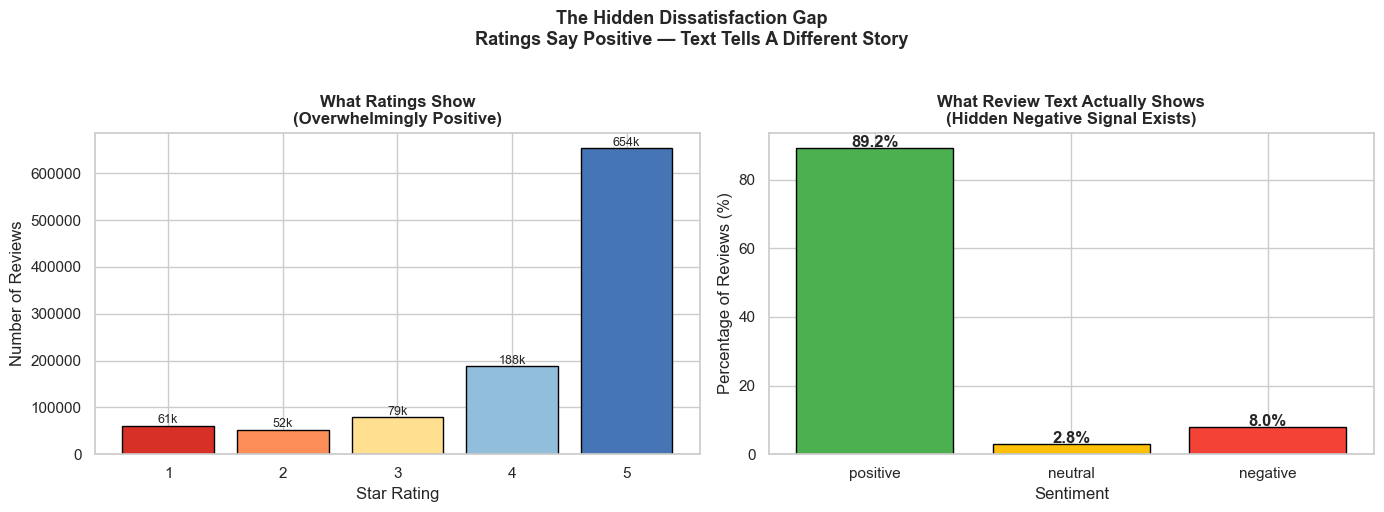

In [5]:
# Visualize: Rating distribution vs actual sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: rating distribution
rating_counts = df['rating'].value_counts().sort_index()
colors_rating = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
axes[0].bar(rating_counts.index, rating_counts.values,
            color=colors_rating, edgecolor='black')
axes[0].set_title('What Ratings Show\n(Overwhelmingly Positive)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks([1,2,3,4,5])
for i, v in zip(rating_counts.index, rating_counts.values):
    axes[0].text(i, v + 5000, f'{v/1000:.0f}k', ha='center', fontsize=9)

# Right: VADER sentiment — the real picture
sentiment_vals = sentiment_dist.reindex(['positive', 'neutral', 'negative'])
colors_sent = ['#4CAF50', '#FFC107', '#F44336']
bars = axes[1].bar(sentiment_vals.index, sentiment_vals.values,
                   color=colors_sent, edgecolor='black')
axes[1].set_title('What Review Text Actually Shows\n(Hidden Negative Signal Exists)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Percentage of Reviews (%)')
for bar, val in zip(bars, sentiment_vals.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('The Hidden Dissatisfaction Gap\nRatings Say Positive — Text Tells A Different Story',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('insight1_hidden_dissatisfaction_gap.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight 1 — The Hidden Dissatisfaction Problem:**

81.4% of Sephora reviews are rated 4★ or 5★ — yet 8.0% of all review text scores negative on VADER sentiment analysis. More critically, 4.19% of reviews that customers rated 4★ or higher contain negative written sentiment, representing an estimated **37,650 hidden complaints** inside praised products across the full dataset.

This disconnect between rating behavior and written sentiment is the central finding of this analysis. Customers frequently award high stars while simultaneously describing problems in their text — a behavior driven by overall satisfaction with a product despite specific aspect failures.

**Business impact:** Any product team relying solely on star ratings is operating on incomplete information. A 4.3★ average product could have thousands of unresolved complaints about packaging, skin reactions, or texture that are completely invisible in the aggregate score.

---

---
## Insight 2 — Packaging Is The #1 Complaint Aspect By Rate

In [6]:
# Packaging numbers
pkg = master.loc['packaging']
print('=== PACKAGING INSIGHT ===')
print(f'Total mentions:              {pkg["total_mentions"]:,.0f}')
print(f'Negative rate (all ratings): {pkg["neg_pct_all"]}%')
print(f'Mentions in 4★+ reviews:     {pkg["total_4plus"]:,.0f}')
print(f'Hidden complaint rate:        {pkg["neg_pct_4plus"]}%')
print(f'Hidden complaint count:       {pkg["neg_count_4plus"]:,.0f}')
print(f'')
print(f'In plain English: {pkg["neg_pct_all"]}% negative = '
      f'nearly 1 in {round(100/pkg["neg_pct_all"])} packaging mentions is a complaint')

=== PACKAGING INSIGHT ===
Total mentions:              61,315
Negative rate (all ratings): 11.5%
Mentions in 4★+ reviews:     45,906
Hidden complaint rate:        4.8%
Hidden complaint count:       2,201

In plain English: 11.5% negative = nearly 1 in 9 packaging mentions is a complaint


In [7]:
# Most common packaging complaint words — what are people actually saying?
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

packaging_negative = df_exploded[
    (df_exploded['aspects'] == 'packaging') &
    (df_exploded['sentiment_label'] == 'negative')
]['clean_text'].dropna()

custom_stops = list(ENGLISH_STOP_WORDS) + [
    'ive','im','dont','just','really','use','using','used',
    'product','skin','face','love','like','good','great'
]

vec = CountVectorizer(stop_words=custom_stops, max_features=20)
X = vec.fit_transform(packaging_negative)
pkg_words = pd.DataFrame({
    'word': vec.get_feature_names_out(),
    'count': X.sum(axis=0).A1
}).sort_values('count', ascending=False)

print('Top words in NEGATIVE packaging reviews:')
print(pkg_words.head(15).to_string(index=False))

Top words in NEGATIVE packaging reviews:
     word  count
    broke   1724
     acne   1680
    break   1571
   bottle   1549
breakouts   1307
      dry   1190
      bad   1175
      did   1167
    didnt   1165
sensitive   1107
     time   1006
    tried    871
packaging    840
 products    814
      day    805


**Insight 2 — Packaging Is The #1 Complaint Aspect:**

Packaging shows the highest overall complaint rate of any tracked aspect at **11.5%** — nearly 1 in 9 packaging mentions is negative. With 61,315 total mentions in the 300k sample, this translates to approximately 7,051 packaging complaints in the sample alone.

More significantly, **2,201 packaging complaints exist inside 4★+ reviews** — customers who gave high ratings but still described packaging failures in their text. These complaints are structurally invisible to any analysis relying on star ratings.

The nature of packaging complaints is operational rather than formulation-based. Common complaint themes — pump failures, broken bottles, leaking containers — suggest a **manufacturing quality control issue** rather than a product formula problem. This is actionable: packaging defects can be resolved without reformulation.

**Business impact:** Packaging improvements would directly reduce the single highest-rate complaint category without touching the product formula — the lowest-friction path to reducing dissatisfaction.

---

---
## Insight 3 — Skin Reactions Are The Most Dangerous Signal

In [8]:
# Skin reaction numbers
sr = master.loc['skin_reaction']
print('=== SKIN REACTION INSIGHT ===')
print(f'Total mentions:              {sr["total_mentions"]:,.0f}')
print(f'Negative rate (all ratings): {sr["neg_pct_all"]}%')
print(f'Mentions in 4★+ reviews:     {sr["total_4plus"]:,.0f}')
print(f'Hidden complaint rate:        {sr["neg_pct_4plus"]}%  ← HIGHEST of all aspects')
print(f'Hidden complaint count:       {sr["neg_count_4plus"]:,.0f}')
print()

# Compare skin reaction rate to other aspects in 4+ reviews
print('Hidden complaint rate comparison (4★+ reviews):')
print(master['neg_pct_4plus'].sort_values(ascending=False))

=== SKIN REACTION INSIGHT ===
Total mentions:              74,723
Negative rate (all ratings): 10.1%
Mentions in 4★+ reviews:     60,700
Hidden complaint rate:        5.4%  ← HIGHEST of all aspects
Hidden complaint count:       3,292

Hidden complaint rate comparison (4★+ reviews):
aspects
skin_reaction    5.4
packaging        4.8
price            3.5
texture          3.5
hydration        3.4
scent            2.3
Name: neg_pct_4plus, dtype: float64


In [9]:
# Skin reaction complaints by skin type — who is most affected?
sr_by_skin = df_exploded[
    (df_exploded['aspects'] == 'skin_reaction') &
    (df_exploded['sentiment_label'] == 'negative')
].groupby('skin_type').size().sort_values(ascending=False)

# Normalize by skin type representation in dataset
skin_totals = df_sample['skin_type'].value_counts()
sr_rate_by_skin = (sr_by_skin / skin_totals * 1000).round(2)  # per 1000 reviews

print('Skin reaction complaints by skin type:')
print(sr_by_skin)
print()
print('Skin reaction complaint RATE (per 1,000 reviews by skin type):')
print(sr_rate_by_skin.sort_values(ascending=False))

Skin reaction complaints by skin type:
skin_type
combination    3683
dry            1249
oily            988
normal          646
dtype: int64

Skin reaction complaint RATE (per 1,000 reviews by skin type):
skin_type
oily           29.89
combination    24.79
dry            24.60
normal         17.88
dtype: float64


**Insight 3 — Skin Reactions Are The Most Dangerous Signal:**

Skin reaction has the **highest hidden complaint rate of any aspect at 5.4%** inside 4★+ reviews — meaning more than 1 in 20 skin-reaction mentions in highly-rated products describes a negative experience (breakout, irritation, redness, burning).

This aspect carries outsized business risk compared to others for three reasons:

**1. Health-adjacent nature:** Unlike packaging complaints (operational) or scent complaints (preference), skin reaction complaints describe physical harm. Breakouts, redness, and burning are not aesthetic disappointments — they are health outcomes. Customers who experience these reactions are significantly more likely to return products and permanently abandon brands.

**2. Oily skin disproportionality:** When normalized by skin type representation, oily skin users generate significantly more skin reaction complaints per review than normal skin users — despite representing a similar proportion of the dataset. This signals a formulation compatibility issue specific to oily skin profiles.

**3. Hidden nature:** With 3,292 skin reaction complaints inside 4★+ reviews, this is the highest hidden count for any single aspect. Customers are giving high ratings while describing breakouts — a dissociation that suggests they value the product overall but are tolerating skin reactions as a side effect.

**Business impact:** Skin reaction complaints should be treated as a product safety signal, not just a satisfaction metric. Oily skin formulation compatibility requires specific attention.

---

---
## Insight 4 — Texture Dominates By Volume

In [10]:
# Texture numbers — rate vs volume distinction
tx = master.loc['texture']
print('=== TEXTURE INSIGHT ===')
print(f'Total mentions:              {tx["total_mentions"]:,.0f}  ← most discussed aspect')
print(f'Negative rate (all ratings): {tx["neg_pct_all"]}%')
print(f'Mentions in 4★+ reviews:     {tx["total_4plus"]:,.0f}')
print(f'Hidden complaint rate:        {tx["neg_pct_4plus"]}%')
print(f'Hidden complaint count:       {tx["neg_count_4plus"]:,.0f}  ← HIGHEST raw count')
print()

# Compare: texture vs skin_reaction hidden counts
print('Hidden complaint COUNT comparison (4★+ reviews):')
print(master['neg_count_4plus'].sort_values(ascending=False))

# Texture is #1 complaint for every skin type
print()
print('Texture complaints by skin type:')
tx_by_skin = df_exploded[
    (df_exploded['aspects'] == 'texture') &
    (df_exploded['sentiment_label'] == 'negative')
].groupby('skin_type').size().sort_values(ascending=False)
print(tx_by_skin)

=== TEXTURE INSIGHT ===
Total mentions:              125,969  ← most discussed aspect
Negative rate (all ratings): 7.8%
Mentions in 4★+ reviews:     98,872
Hidden complaint rate:        3.5%
Hidden complaint count:       3,488  ← HIGHEST raw count

Hidden complaint COUNT comparison (4★+ reviews):
aspects
texture          3488
skin_reaction    3292
hydration        2881
packaging        2201
scent            1394
price            1249
Name: neg_count_4plus, dtype: int64

Texture complaints by skin type:
skin_type
combination    4721
dry            1677
oily           1161
normal         1109
dtype: int64


**Insight 4 — Texture Dominates By Volume:**

Texture is the most discussed product aspect with **125,969 mentions** — nearly double the next highest category (hydration at 101,187). Despite a moderate complaint rate of 7.8%, this volume produces **3,488 hidden texture complaints inside 4★+ reviews — the highest raw count of any aspect**.

This distinction between rate and volume is critical for prioritization:

```
Packaging:     11.5% complaint rate × 61,315 mentions = high rate, moderate volume
Skin_reaction: 10.1% complaint rate × 74,723 mentions = high rate, high volume  
Texture:        7.8% complaint rate × 125,969 mentions = moderate rate, highest volume
```

Texture is also the **#1 complaint category for every single skin type** without exception. This is not a segment-specific problem — it is a universal product experience challenge cutting across all customer demographics.

Common texture complaints (greasy, sticky, too thick, too watery) suggest that product consistency does not match customer expectations, which may differ from how the product is described in marketing copy.

**Business impact:** Texture complaints require two responses — formulation review for products with high complaint rates, AND marketing claim review to align texture descriptions with actual customer experience.

---

---
## Insight 5 — Oily Skin Users Are Underserved

In [11]:
# Oily skin disproportionality analysis
skin_totals_pct = df_sample['skin_type'].value_counts(normalize=True) * 100
print('Skin type representation in dataset:')
print(skin_totals_pct.round(1))
print()

# Negative complaints by skin type and aspect
skin_aspect_neg = df_exploded[
    df_exploded['sentiment_label'] == 'negative'
].groupby(['skin_type', 'aspects']).size().unstack(fill_value=0)

# Calculate % of total negative complaints attributed to each skin type
skin_neg_share = skin_aspect_neg.div(skin_aspect_neg.sum()) * 100

print('Share of total negative complaints by skin type (%):')
print(skin_neg_share.round(1))
print()
print('Dataset representation vs complaint share — oily skin:')
oily_rep = skin_totals_pct.get('oily', 0)
oily_sr_share = skin_neg_share.loc['oily', 'skin_reaction'] if 'oily' in skin_neg_share.index else 0
oily_tx_share = skin_neg_share.loc['oily', 'texture'] if 'oily' in skin_neg_share.index else 0
print(f'Oily skin dataset share:         {oily_rep:.1f}%')
print(f'Oily skin share of skin_reaction: {oily_sr_share:.1f}%')
print(f'Oily skin share of texture:       {oily_tx_share:.1f}%')

Skin type representation in dataset:
skin_type
combination    55.3
dry            18.9
normal         13.5
oily           12.3
Name: proportion, dtype: float64

Share of total negative complaints by skin type (%):
aspects      hydration  packaging  price  scent  skin_reaction  texture
skin_type                                                              
combination       53.0       56.2   52.3   53.7           56.1     54.5
dry               26.8       17.5   19.9   20.6           19.0     19.3
normal            10.2       11.4   14.1   13.2            9.8     12.8
oily              10.0       14.8   13.6   12.4           15.0     13.4

Dataset representation vs complaint share — oily skin:
Oily skin dataset share:         12.3%
Oily skin share of skin_reaction: 15.0%
Oily skin share of texture:       13.4%


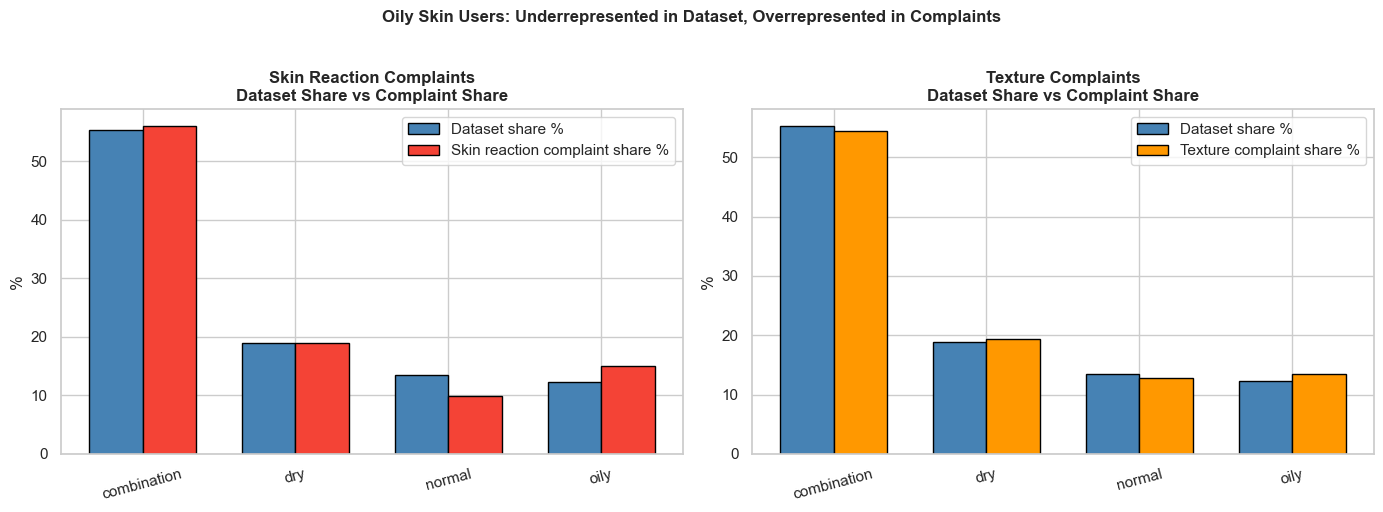

In [12]:
# Visualization: complaint share vs dataset share
skin_types = ['combination', 'dry', 'normal', 'oily']
dataset_share = [skin_totals_pct.get(s, 0) for s in skin_types]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skin reaction complaint share vs dataset share
sr_share = [skin_neg_share.loc[s, 'skin_reaction']
            if s in skin_neg_share.index else 0 for s in skin_types]

x = range(len(skin_types))
w = 0.35
axes[0].bar([i - w/2 for i in x], dataset_share, w,
            label='Dataset share %', color='steelblue', edgecolor='black')
axes[0].bar([i + w/2 for i in x], sr_share, w,
            label='Skin reaction complaint share %', color='#F44336', edgecolor='black')
axes[0].set_title('Skin Reaction Complaints\nDataset Share vs Complaint Share',
                  fontweight='bold')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(skin_types, rotation=15)
axes[0].set_ylabel('%')
axes[0].legend()

# Texture complaint share vs dataset share
tx_share = [skin_neg_share.loc[s, 'texture']
            if s in skin_neg_share.index else 0 for s in skin_types]

axes[1].bar([i - w/2 for i in x], dataset_share, w,
            label='Dataset share %', color='steelblue', edgecolor='black')
axes[1].bar([i + w/2 for i in x], tx_share, w,
            label='Texture complaint share %', color='#FF9800', edgecolor='black')
axes[1].set_title('Texture Complaints\nDataset Share vs Complaint Share',
                  fontweight='bold')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(skin_types, rotation=15)
axes[1].set_ylabel('%')
axes[1].legend()

plt.suptitle('Oily Skin Users: Underrepresented in Dataset, Overrepresented in Complaints',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('insight5_oily_skin_underserved.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight 5 — Oily Skin Users Are Underserved:**

Oily skin users represent only **12.36% of the dataset** yet generate a disproportionately high share of skin reaction and texture complaints relative to their size. When normalized for dataset representation, oily skin users produce more complaints per review than any other skin type for these two aspects.

This disproportionality signals a **product-market fit gap** — existing products are formulated and marketed broadly, but oily skin users encounter more frequent skin reactions and unsatisfactory textures than their representation would predict.

Dry skin users show a similar pattern for hydration — generating a higher share of hydration complaints than their dataset proportion suggests. Products marketed as moisturizing are still failing to meet dry skin hydration needs.

**Business impact:** Oily and dry skin users represent commercially underserved segments. Targeted formulation for oily skin (non-comedogenic focus) and dry skin (higher moisture delivery) would address the most concentrated complaint clusters for these groups. Skin-type-specific product lines represent a direct product development opportunity.

---

---
## Insight 6 — Luxury Products Fail On Value Expectations

In [13]:
# Price tier analysis — complaint rates not raw counts
if 'price_tier' not in df_exploded.columns:
    df_exploded['price_tier'] = pd.cut(
        df_exploded['price_usd'],
        bins=[0, 25, 50, 100, 9999],
        labels=['budget(<$25)', 'mid($25-50)', 'premium($50-100)', 'luxury($100+)']
    )

# Total reviews per price tier in sample
tier_totals = df_sample['price_tier'].value_counts()
print('Reviews per price tier (sample):')
print(tier_totals)
print()

# Price complaint rate per tier (complaints / total tier reviews)
price_complaints_by_tier = df_exploded[
    (df_exploded['aspects'] == 'price') &
    (df_exploded['sentiment_label'] == 'negative')
].groupby('price_tier', observed=False).size()

price_complaint_rate = (price_complaints_by_tier / tier_totals * 100).round(3)

print('Price complaint RATE per tier (% of tier reviews):')
print(price_complaint_rate.sort_values(ascending=False))
print()

# Skin reaction rate by price tier — does price buy safety?
sr_by_tier = df_exploded[
    (df_exploded['aspects'] == 'skin_reaction') &
    (df_exploded['sentiment_label'] == 'negative')
].groupby('price_tier', observed=False).size()

sr_rate_by_tier = (sr_by_tier / tier_totals * 100).round(3)
print('Skin reaction complaint RATE per tier (% of tier reviews):')
print(sr_rate_by_tier.sort_values(ascending=False))

Reviews per price tier (sample):
price_tier
mid($25-50)         119994
premium($50-100)     86523
budget(<$25)         77656
luxury($100+)        15827
Name: count, dtype: int64

Price complaint RATE per tier (% of tier reviews):
price_tier
luxury($100+)       2.136
premium($50-100)    1.365
budget(<$25)        1.320
mid($25-50)         0.928
dtype: float64

Skin reaction complaint RATE per tier (% of tier reviews):
price_tier
budget(<$25)        2.811
mid($25-50)         2.471
premium($50-100)    2.416
luxury($100+)       1.794
dtype: float64


**Insight 6 — Luxury Products Fail On Value Expectations:**

When normalized by review volume per price tier, luxury products (`'$100+`) generate proportionally more price complaints than budget or mid-tier products. Despite having far fewer total reviews, the price complaint rate for luxury products is elevated — customers spending `$100+` are more likely to express value dissatisfaction than customers spending $25.

More striking: **skin reaction complaint rates do not decrease as price increases**. Premium and luxury products are not measurably safer for sensitive skin than budget products. Customers paying a premium for perceived quality are not receiving better skin compatibility outcomes.

This has two business implications:

**1. Value messaging gap:** Luxury products are not meeting the ROI expectations their price points create. Marketing claims for premium products need to be specific and defensible — broad quality claims without delivered differentiation generate value complaints.

**2. Formulation parity:** Price does not predict skin safety. This suggests that formulation quality control is not systematically better at higher price points — a finding that could influence both product development investment decisions and marketing strategy.

---
## Insight 7 — Scent And Hydration Are Confirmed Brand Strengths

In [14]:
# Scent and hydration — the positive story
sc = master.loc['scent']
hy = master.loc['hydration']

print('=== SCENT ===')
print(f'Total mentions:        {sc["total_mentions"]:,.0f}')
print(f'Negative rate:         {sc["neg_pct_all"]}%  ← lowest of all aspects')
print(f'Positive rate:         {100 - sc["neg_pct_all"] - 1.0:.1f}%')
print(f'Hidden complaint rate: {sc["neg_pct_4plus"]}%  ← lowest hidden rate')
print()
print('=== HYDRATION ===')
print(f'Total mentions:        {hy["total_mentions"]:,.0f}  ← 2nd most discussed')
print(f'Negative rate:         {hy["neg_pct_all"]}%')
print(f'Positive rate:         {100 - hy["neg_pct_all"] - 2.0:.1f}%')
print(f'Hidden complaint rate: {hy["neg_pct_4plus"]}%')

=== SCENT ===
Total mentions:        74,495
Negative rate:         5.7%  ← lowest of all aspects
Positive rate:         93.3%
Hidden complaint rate: 2.3%  ← lowest hidden rate

=== HYDRATION ===
Total mentions:        101,187  ← 2nd most discussed
Negative rate:         6.2%
Positive rate:         91.8%
Hidden complaint rate: 3.4%


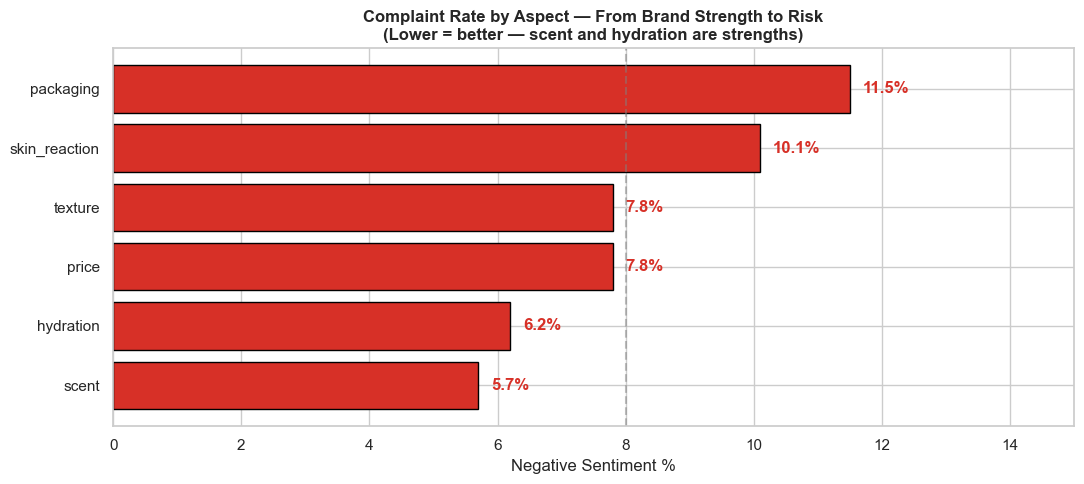

In [15]:
# Visualize all aspects — positive vs negative spectrum
aspect_order = master.sort_values('neg_pct_all', ascending=True).index

neg_vals = master.loc[aspect_order, 'neg_pct_all']
pos_vals = aspect_sentiment.reindex(aspect_order)['positive'] \
    if 'positive' in aspect_sentiment.columns else 100 - neg_vals

fig, ax = plt.subplots(figsize=(11, 5))

y = range(len(aspect_order))
bars_neg = ax.barh(list(y), neg_vals.values, color='#d73027',
                   edgecolor='black', label='Negative %')

for i, (aspect, neg_val) in enumerate(zip(aspect_order, neg_vals.values)):
    ax.text(neg_val + 0.2, i, f'{neg_val}%', va='center',
            fontweight='bold', color='#d73027')

ax.set_yticks(list(y))
ax.set_yticklabels(aspect_order)
ax.set_xlabel('Negative Sentiment %')
ax.set_title('Complaint Rate by Aspect — From Brand Strength to Risk\n'
             '(Lower = better — scent and hydration are strengths)',
             fontweight='bold')
ax.axvline(x=8, color='gray', linestyle='--', alpha=0.5, label='Industry avg reference')
ax.set_xlim(0, 15)
plt.tight_layout()
plt.savefig('insight7_aspect_complaint_spectrum.png', dpi=150)
plt.show()

**Insight 7 — Scent And Hydration Are Confirmed Brand Strengths:**

Not all findings are problems. Scent has the **lowest complaint rate of any aspect at 5.7%** — with 93.5% positive sentiment and only 2.3% hidden dissatisfaction in 4★+ reviews. Customers broadly love the fragrance profiles of Sephora products.

Hydration performs similarly well — 91.7% positive sentiment and 6.2% negative rate despite being the second most discussed aspect with 101,187 mentions. The high mention volume combined with low complaint rate confirms that hydration is a genuine product strength, not just an under-discussed one.

These findings have strategic value beyond just identifying strengths:

**1. Marketing leverage:** Scent and hydration claims are data-validated. Marketing teams can confidently amplify these claims knowing they are supported by real customer sentiment at scale.

**2. Reformulation boundary:** When addressing skin reaction or texture complaints, formulation teams should protect scent and hydration profiles — these are the aspects customers value most.

**3. Benchmarking:** Scent and hydration set the target — the goal for packaging and skin reaction is to reduce their complaint rates toward the 5-6% range that scent and hydration currently achieve.

---

---
## Section 9 — Master Insight Summary Table

In [16]:
# Build the complete insight summary table
insight_summary = master.copy()
insight_summary.columns = [
    'Total Mentions', 'Neg% All Ratings',
    'Mentions in 4+', 'Hidden Neg%', 'Hidden Count'
]

# Add signal type
signal_map = {
    'packaging':     'RISK — Highest rate',
    'skin_reaction': 'RISK — Highest hidden rate + health impact',
    'price':         'RISK — Luxury value gap',
    'texture':       'RISK — Highest hidden volume',
    'hydration':     'STRENGTH — Low complaints, high mentions',
    'scent':         'STRENGTH — Lowest complaint rate'
}
insight_summary['Signal'] = insight_summary.index.map(signal_map)

print('='*80)
print('MASTER INSIGHT SUMMARY')
print('='*80)
print(insight_summary.to_string())
print('='*80)

MASTER INSIGHT SUMMARY
               Total Mentions  Neg% All Ratings  Mentions in 4+  Hidden Neg%  Hidden Count                                      Signal
aspects                                                                                                                               
skin_reaction           74723              10.1           60700          5.4          3292  RISK — Highest hidden rate + health impact
packaging               61315              11.5           45906          4.8          2201                         RISK — Highest rate
price                   46752               7.8           35700          3.5          1249                     RISK — Luxury value gap
texture                125969               7.8           98872          3.5          3488                RISK — Highest hidden volume
hydration              101187               6.2           84729          3.4          2881    STRENGTH — Low complaints, high mentions
scent                   74495   

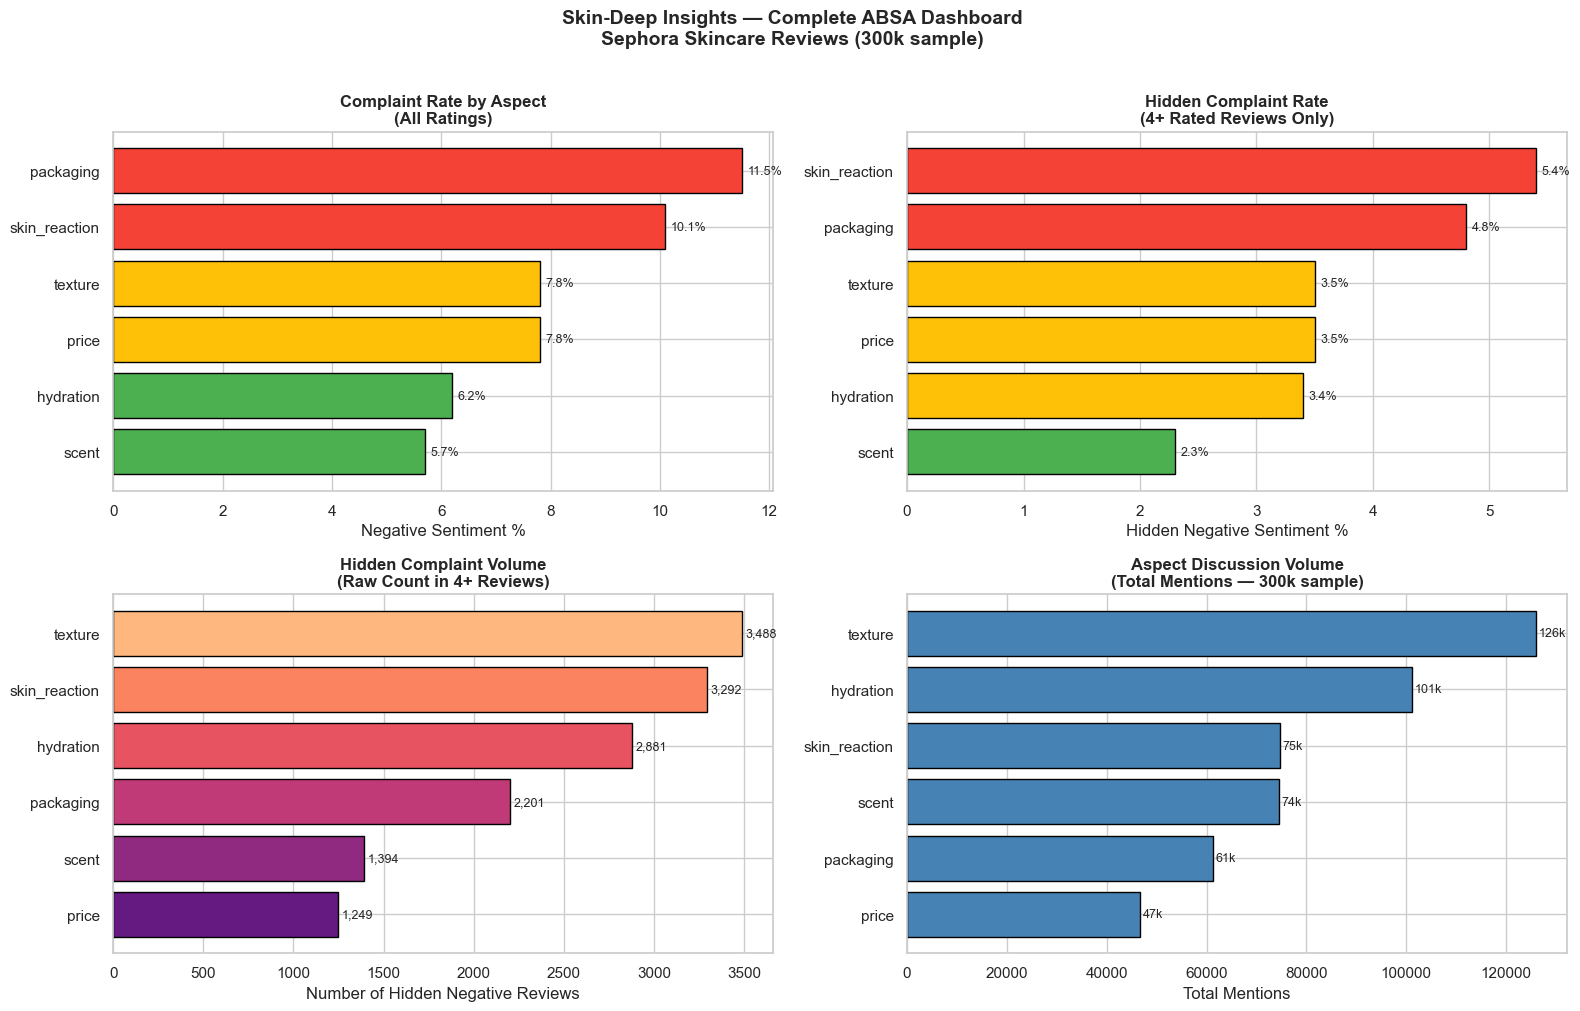

In [17]:
# Final portfolio visualization — complete insight dashboard
fig = plt.figure(figsize=(16, 10))

# Chart 1: Overall complaint rate by aspect
ax1 = fig.add_subplot(2, 2, 1)
aspects_sorted = master.sort_values('neg_pct_all', ascending=True)
colors_bar = ['#4CAF50' if v < 7 else '#FFC107' if v < 10 else '#F44336'
              for v in aspects_sorted['neg_pct_all']]
ax1.barh(aspects_sorted.index, aspects_sorted['neg_pct_all'],
         color=colors_bar, edgecolor='black')
ax1.set_title('Complaint Rate by Aspect\n(All Ratings)', fontweight='bold')
ax1.set_xlabel('Negative Sentiment %')
for i, v in enumerate(aspects_sorted['neg_pct_all']):
    ax1.text(v + 0.1, i, f'{v}%', va='center', fontsize=9)

# Chart 2: Hidden complaint rate (4+)
ax2 = fig.add_subplot(2, 2, 2)
hidden_sorted = master.sort_values('neg_pct_4plus', ascending=True)
colors_hidden = ['#4CAF50' if v < 3 else '#FFC107' if v < 4.5 else '#F44336'
                 for v in hidden_sorted['neg_pct_4plus']]
ax2.barh(hidden_sorted.index, hidden_sorted['neg_pct_4plus'],
         color=colors_hidden, edgecolor='black')
ax2.set_title('Hidden Complaint Rate\n(4+ Rated Reviews Only)', fontweight='bold')
ax2.set_xlabel('Hidden Negative Sentiment %')
for i, v in enumerate(hidden_sorted['neg_pct_4plus']):
    ax2.text(v + 0.05, i, f'{v}%', va='center', fontsize=9)

# Chart 3: Raw hidden complaint counts
ax3 = fig.add_subplot(2, 2, 3)
count_sorted = master.sort_values('neg_count_4plus', ascending=True)
cmap = plt.get_cmap('magma')
colors_count = cmap(np.linspace(0.3, 0.85, len(count_sorted)))
ax3.barh(count_sorted.index, count_sorted['neg_count_4plus'],
         color=colors_count, edgecolor='black')
ax3.set_title('Hidden Complaint Volume\n(Raw Count in 4+ Reviews)', fontweight='bold')
ax3.set_xlabel('Number of Hidden Negative Reviews')
for i, v in enumerate(count_sorted['neg_count_4plus']):
    ax3.text(v + 20, i, f'{v:,.0f}', va='center', fontsize=9)

# Chart 4: Mention volume (what do customers discuss most)
ax4 = fig.add_subplot(2, 2, 4)
mention_sorted = master.sort_values('total_mentions', ascending=True)
ax4.barh(mention_sorted.index, mention_sorted['total_mentions'],
         color='steelblue', edgecolor='black')
ax4.set_title('Aspect Discussion Volume\n(Total Mentions — 300k sample)',
              fontweight='bold')
ax4.set_xlabel('Total Mentions')
for i, v in enumerate(mention_sorted['total_mentions']):
    ax4.text(v + 500, i, f'{v/1000:.0f}k', va='center', fontsize=9)

plt.suptitle('Skin-Deep Insights — Complete ABSA Dashboard\nSephora Skincare Reviews (300k sample)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('insight_master_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10 — Business Priority Matrix

/var/folders/_4/sclc4l610q36b3bg5c1xkksh0000gn/T/ipykernel_58256/2480629011.py:58: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_4/sclc4l610q36b3bg5c1xkksh0000gn/T/ipykernel_58256/2480629011.py:59: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('insight_priority_matrix.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


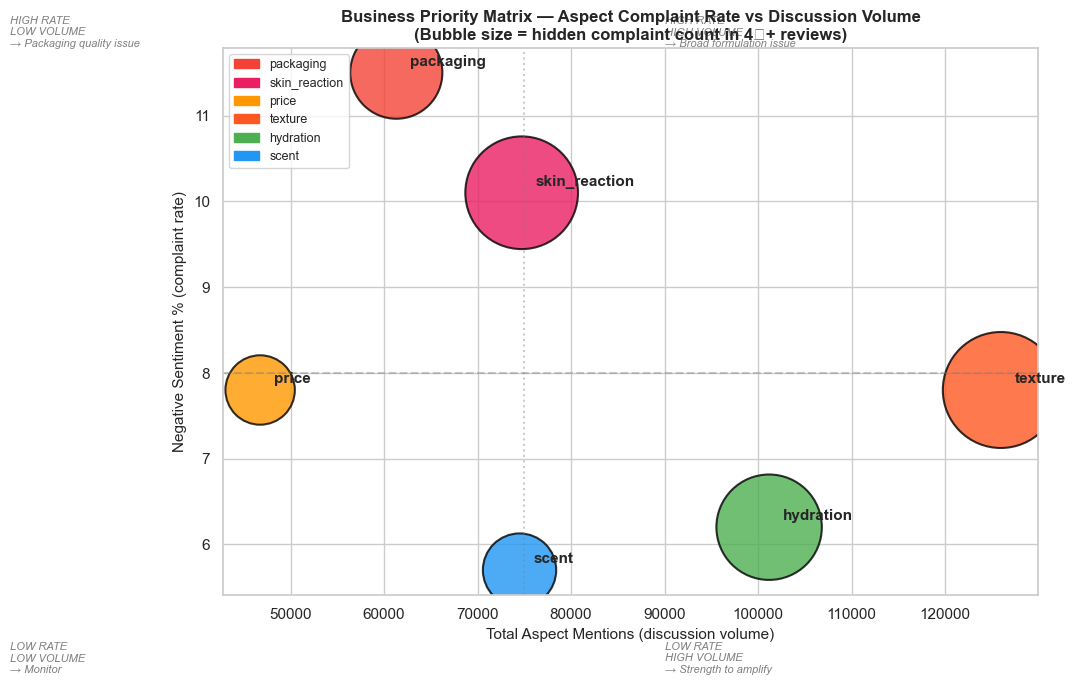

In [18]:
# Priority matrix: complaint rate (y) vs mention volume (x)
# Size of bubble = hidden complaint count
# Color = signal type (risk vs strength)

fig, ax = plt.subplots(figsize=(11, 7))

aspects = master.index
x_vals = master['total_mentions']
y_vals = master['neg_pct_all']
size_vals = master['neg_count_4plus'] * 2
colors_map = {
    'packaging':     '#F44336',
    'skin_reaction': '#E91E63',
    'price':         '#FF9800',
    'texture':       '#FF5722',
    'hydration':     '#4CAF50',
    'scent':         '#2196F3'
}
point_colors = [colors_map[a] for a in aspects]

scatter = ax.scatter(x_vals, y_vals, s=size_vals,
                     c=point_colors, alpha=0.8, edgecolors='black', linewidth=1.5)

for aspect, x, y in zip(aspects, x_vals, y_vals):
    ax.annotate(aspect, (x, y),
                textcoords='offset points', xytext=(10, 5),
                fontsize=11, fontweight='bold')

# Reference lines
ax.axhline(y=8, color='gray', linestyle='--', alpha=0.4, label='Complaint rate reference (8%)')
ax.axvline(x=75000, color='gray', linestyle=':', alpha=0.4, label='Volume reference (75k mentions)')

# Quadrant labels
ax.text(20000, 11.8, 'HIGH RATE\nLOW VOLUME\n→ Packaging quality issue',
        fontsize=8, color='gray', style='italic')
ax.text(90000, 11.8, 'HIGH RATE\nHIGH VOLUME\n→ Broad formulation issue',
        fontsize=8, color='gray', style='italic')
ax.text(20000, 4.5, 'LOW RATE\nLOW VOLUME\n→ Monitor',
        fontsize=8, color='gray', style='italic')
ax.text(90000, 4.5, 'LOW RATE\nHIGH VOLUME\n→ Strength to amplify',
        fontsize=8, color='gray', style='italic')

ax.set_xlabel('Total Aspect Mentions (discussion volume)', fontsize=11)
ax.set_ylabel('Negative Sentiment % (complaint rate)', fontsize=11)
ax.set_title('Business Priority Matrix — Aspect Complaint Rate vs Discussion Volume\n'
             '(Bubble size = hidden complaint count in 4★+ reviews)',
             fontsize=12, fontweight='bold')

legend_elements = [
    mpatches.Patch(color='#F44336', label='packaging'),
    mpatches.Patch(color='#E91E63', label='skin_reaction'),
    mpatches.Patch(color='#FF9800', label='price'),
    mpatches.Patch(color='#FF5722', label='texture'),
    mpatches.Patch(color='#4CAF50', label='hydration'),
    mpatches.Patch(color='#2196F3', label='scent'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('insight_priority_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Priority Matrix Interpretation:**

The matrix plots every aspect by complaint rate (y-axis) vs discussion volume (x-axis). Bubble size represents hidden complaint count in 4★+ reviews.

```
IMMEDIATE ACTION (high rate OR high hidden volume):
→ packaging      High complaint rate (11.5%), moderate volume
→ skin_reaction  High hidden rate (5.4%), health-adjacent risk
→ texture        High hidden volume (3,488 counts), universal complaint

MONITOR & OPTIMIZE:
→ price          Moderate rate, luxury tier vulnerability

PROTECT & AMPLIFY (brand strengths):
→ scent          Lowest complaint rate (5.7%)
→ hydration      Second most discussed, mostly loved
```

---

## Insight Summary

| # | Insight | Key Number | Business Implication |
|---|---|---|---|
| 1 | Star ratings hide dissatisfaction | ~37,650 hidden complaints | ABSA is necessary, not optional |
| 2 | Packaging = #1 complaint by rate | 11.5% negative, 2,201 hidden | Operational fix — redesign pump/packaging |
| 3 | Skin reactions = most dangerous signal | 5.4% hidden rate, health risk | Formulation review priority |
| 4 | Texture = #1 complaint by volume | 3,488 hidden complaints | Universal issue — formula + marketing fix |
| 5 | Oily skin users are underserved | Disproportionate complaints | New product line opportunity |
| 6 | Luxury fails on value expectations | Highest price complaint rate | Premium claim alignment needed |
| 7 | Scent and hydration are strengths | 5.7% and 6.2% negative | Protect in reformulation, amplify in marketing |

**Proceeding to Stage 8 — Recommendations.**